# Lab 01 · Continuous risk identification
**risk.engineer · Risk engineering lifecycle, step 1**

A security tool produces events. A business system supplies context. Neither produces a risk statement by itself.

In this lab, you will run a repeatable data pipeline that turns **49,200 vendor-shaped mock records** into a small set of cited candidate risk statements:

`Okta + Zscaler → validation → OCSF → business context → bounded clusters → agent investigation → human review`

The pipeline identifies plausible scenarios. It does **not** score likelihood, rate impact, prioritize, recommend treatment, or accept risk.

**Time:** 45–60 minutes · **Cost:** $0 in replay mode; variable in live mode · **Prerequisites:** basic Python/JSON and either Python 3.12 or Docker

**Learning objectives**

1. Land and receipt multiple changing sources without losing provenance.
2. Map vendor fields to validated OCSF events while keeping business context separate.
3. Use an agent to investigate every bounded cluster and abstain when the evidence is incomplete, contradictory, or ambiguous.
4. Validate citations and measure the workflow against known synthetic cases.

**Expected output:** a visual candidate-risk register, an evidence graph, batch history, the full agent tool trace, and a machine-readable evaluation scorecard.

In [1]:
import json
from pathlib import Path
import duckdb
from IPython.display import display, Markdown
from fixture_factory import generate
from ingestion import ingest
from pipeline import build_warehouse, correlate
from engine import run, VERSION
from evaluation import evaluate
from visuals import show_volume, show_funnel, show_evidence, show_investigation_board, show_register, show_history

ROOT = Path.cwd()
LIVE = False  # True makes paid API calls using OPENAI_API_KEY. False replays saved real model traces.
display(Markdown("**Mode:** " + ("live bounded model run" if LIVE else "saved real model output over regenerated mock evidence")))

**Mode:** saved real model output over regenerated mock evidence

## 1 · Begin with the objective, not the alert

The fictional organization needs former-worker access removed so customer information, financial reporting, and software delivery remain protected. NIST CSF outcome **PR.AA-05** supplies target-profile context: access permissions are managed, enforced, and reviewed.

This is not a maturity score. It tells us which desired outcome may be affected. The security evidence still has to support a condition, and a plausible threat event still has to connect that condition to a potential consequence.

In [2]:
manifest = generate(ROOT)
manifest

{'seed': 41,
 'source_kind': 'deterministic mock data shaped like documented vendor exports',
 'counts': {'hr': 1000,
  'okta': 8000,
  'zscaler': 40000,
  'business_services': 200},
 'batches': [1, 2],
 'generated_for': 'risk.engineer Lab 01; not production telemetry'}

## 2 · Register, land and receipt every source

The fixture factory stands in for upstream collectors. It produces deterministic JSON shaped like records teams receive from Okta System Log and Zscaler NSS. HR and the service catalog provide separate context. These are mock records—no vendor tenant or real person is represented.

Ingestion is a separate boundary. A source registry declares the role, format, adapter, identity field and batch field for every feed. The ingestor copies each file into a content-addressed landing path, calculates a SHA-256 checksum, counts records and batches, reports missing or duplicate source IDs, and issues a validated receipt. Reprocessing the same files produces the same receipt and does not duplicate the landed object.

This stage does not decide whether a security record is meaningful or ask an LLM to repair it. A valid JSON record may still fail vendor mapping or OCSF validation later.

At this volume, the lesson is visible: sending every event to a model would be expensive, hard to audit, and unnecessary.

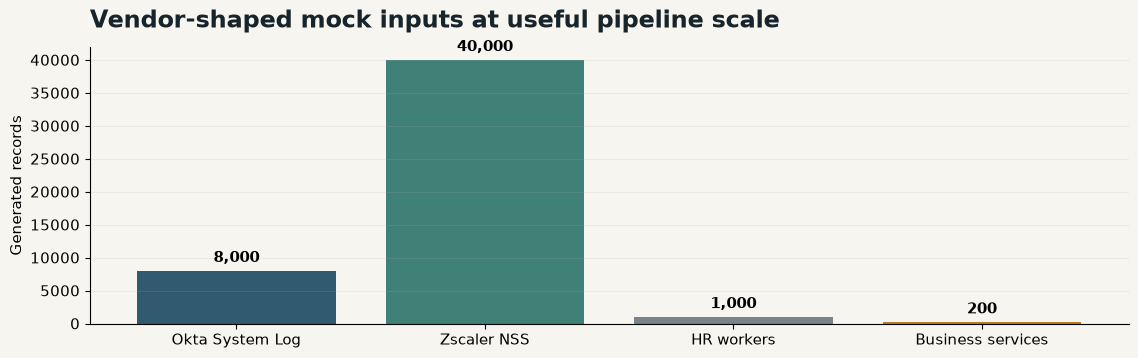

[{'source': 'Okta System Log',
  'role': 'security-telemetry',
  'records': 8000,
  'batches': {'1': 4003, '2': 3997},
  'status': 'accepted-with-envelope-warnings',
  'sha256': '76a30700743d…'},
 {'source': 'Zscaler NSS Web',
  'role': 'security-telemetry',
  'records': 40000,
  'batches': {'1': 20002, '2': 19998},
  'status': 'accepted-with-envelope-warnings',
  'sha256': '7b8ee77bcf8c…'},
 {'source': 'HRIS worker snapshot',
  'role': 'identity-context',
  'records': 1000,
  'batches': 'snapshot',
  'status': 'accepted',
  'sha256': '3fa8ecd749e8…'},
 {'source': 'Business service catalog',
  'role': 'business-context',
  'records': 200,
  'batches': 'snapshot',
  'status': 'accepted',
  'sha256': '1d3bf5e11092…'}]

{'Okta source record': {'uuid': 'OKTA-N-00000',
  'published': '2026-09-01T12:00:00Z',
  'eventType': 'user.authentication.sso',
  'outcome': {'result': 'SUCCESS'},
  'actor': {'id': '00u0010',
   'type': 'User',
   'alternateId': 'user0010@corp.example.test',
   'displayName': 'user0010'},
  'client': {'ipAddress': '198.51.100.11'},
  'target': [{'id': '00u0010',
    'type': 'User',
    'alternateId': 'user0010@corp.example.test',
    'displayName': 'user0010'},
   {'id': '0oa00000',
    'type': 'AppInstance',
    'alternateId': 'support',
    'displayName': 'Support'}],
  '_collection': {'batch_id': 1,
   'source': 'okta-system-log',
   'complete': True}}}

{'Zscaler source record': {'datetime': '2026-09-01T12:00:00Z',
  'event_id': 'ZIA-N-00000',
  'action': 'Allowed',
  'user': 'user0010@corp.example.test',
  'login': 'user0010@corp.example.test',
  'url': 'https://support.apps.example.test/records',
  'urlcategory': 'Business Use',
  'hostname': 'support.apps.example.test',
  'ClientIP': '203.0.113.11',
  'requestmethod': 'GET',
  'product': 'NSS',
  'vendor': 'Zscaler',
  '_collection': {'batch_id': 1,
   'source': 'zscaler-nss-web',
   'complete': True}}}

Ingestion run: d65020b6c5439dd9 · ready for: ['leaver-access-v1']


In [3]:
receipt = ingest(ROOT)
show_volume({'pipeline': {'manifest': {'raw_counts': receipt['counts']}}})
display([{
    'source': source['label'], 'role': source['role'], 'records': source['record_count'],
    'batches': source['batch_counts'] or 'snapshot', 'status': source['transport_status'],
    'sha256': source['sha256'][:12] + '…'
} for source in receipt['sources']])

def first_jsonl(path):
    with path.open(encoding='utf-8') as handle:
        return json.loads(next(handle))

display({'Okta source record': first_jsonl(ROOT / 'data/raw/okta_system_log.jsonl')})
display({'Zscaler source record': first_jsonl(ROOT / 'data/raw/zscaler_nss_web.jsonl')})
print('Ingestion run:', receipt['run_id'], '· ready for:', receipt['ready_for'])

## 3 · Validate and normalize landed telemetry to OCSF

The pipeline reads the landed copies referenced by the receipt. It rejects malformed source rows into quarantine. Valid Okta and Zscaler records are mapped to OCSF 1.8.0 classes and checked against the packaged OCSF JSON Schema before they are written to Parquet.

- Okta authentication → **Authentication [3002]**
- Okta account deactivation → **Account Change [3001]**
- Zscaler web request → **HTTP Activity [4002]**

HR and business-service data remain enrichment. Forcing them into a security-event schema would erase useful meaning.

### The adapter is an explicit field contract

| Source field | OCSF / query projection | Why it survives |
|---|---|---|
| Okta `published` | `time` | orders identity activity |
| Okta `uuid` | `metadata.original_event_uid` | preserves source provenance |
| Okta target user | `user` | supports identity joins |
| Okta target app | `service` | connects access to a business service |
| Okta `outcome.result` | `status_id` | distinguishes successful activity |
| Zscaler `datetime` | `time` | aligns web and identity timelines |
| Zscaler `event_id` | `metadata.original_event_uid` | preserves source provenance |
| Zscaler `login` | `src_endpoint.owner.name` | supports identity correlation |
| Zscaler `hostname` | `dst_endpoint.hostname` | resolves the destination service |
| Zscaler `url` / `requestmethod` | `http_request` | retains the observed request |

The normalized event is not invented by the model. An adapter performs this mapping and OCSF Schema validation determines whether the result is accepted.

In [4]:
warehouse = build_warehouse(ROOT)
display(warehouse)

con = duckdb.connect()
try:
    con.read_parquet(str(ROOT / 'data/normalized/ocsf_events.parquet')).create_view('events')
    sample = con.execute("SELECT source, evidence_id, class_uid, activity_id, ocsf_json FROM events WHERE evidence_id='OKTA-P1'").fetchone()
finally:
    con.close()
display({'source': sample[0], 'evidence_id': sample[1], 'class_uid': sample[2], 'activity_id': sample[3], 'ocsf_event': json.loads(sample[4])})

{'mapping_version': '4',
 'ingestion_run_id': 'd65020b6c5439dd9',
 'ingestion_registry_version': '1.0.0',
 'ingestion_ready_for': ['leaver-access-v1'],
 'ocsf_version': '1.8.0',
 'raw_counts': {'okta': 8000,
  'zscaler': 40000,
  'hr': 1000,
  'business_services': 200},
 'normalized_events': 47998,
 'quarantined': 2,
 'class_counts': {'authentication': 7997,
  'account_change': 2,
  'http_activity': 39999},
 'validation': 'Every emitted event passed the packaged OCSF 1.8.0 JSON Schema for its class.',
 'provenance': {'raw': 'deterministic mock data shaped like documented vendor exports',
  'normalized': 'OCSF projection plus query index columns',
  'context': 'fictional HR and business-service enrichment'}}

{'source': 'okta',
 'evidence_id': 'OKTA-P1',
 'class_uid': 3002,
 'activity_id': 1,
 'ocsf_event': {'category_uid': 3,
  'metadata': {'version': '1.8.0',
   'product': {'vendor_name': 'Okta', 'name': 'System Log'},
   'original_event_uid': 'OKTA-P1'},
  'severity_id': 1,
  'time': 1788264720000,
  'status_id': 1,
  'user': {'uid': '00u0001', 'name': 'user0001@corp.example.test'},
  'class_name': 'Authentication',
  'activity_name': 'Logon',
  'type_name': 'Authentication: Logon',
  'activity_id': 1,
  'class_uid': 3002,
  'type_uid': 300201,
  'service': {'uid': '0oa00000', 'name': 'support'}}}

## 4 · Form an investigation queue

DuckDB groups observations by worker login and expected service, retaining all observed identity UIDs. A login match is a lead; a unique identity consistent with HR is required before supporting this scenario.

Our reference method requires successful authentication and allowed web activity after termination and after the latest observed disable, if present. Multiple or conflicting identities mean ambiguity; no observed identity means insufficient evidence. A disable with no later qualifying activity contradicts the narrow condition for this window only.

These conditions define one scenario family. The method is visible in code for comparison, while the agent receives the facts without the reference labels.

In [5]:
pipelines = [correlate(1, ROOT), correlate(2, ROOT)]
display([{k: c[k] for k in ('person_id', 'service_id', 'identity_uids', 'evidence_ids')} for c in pipelines[0]['clusters']])

[{'person_id': 'P0001',
  'service_id': 'support',
  'identity_uids': ['00u0001'],
  'evidence_ids': ['HR-0001', 'OKTA-P1', 'ZIA-P1']},
 {'person_id': 'P0002',
  'service_id': 'support',
  'identity_uids': ['00u0002A', '00u0002B'],
  'evidence_ids': ['HR-0002', 'OKTA-P2A', 'OKTA-P2B', 'ZIA-P2']},
 {'person_id': 'P0003',
  'service_id': 'support',
  'identity_uids': ['00u0003'],
  'evidence_ids': ['HR-0003', 'OKTA-P3-DISABLE']},
 {'person_id': 'P0004',
  'service_id': 'support',
  'identity_uids': ['00u0004'],
  'evidence_ids': ['HR-0004', 'OKTA-P4']},
 {'person_id': 'P0005',
  'service_id': 'finance',
  'identity_uids': ['00u0005'],
  'evidence_ids': ['HR-0005', 'OKTA-P5', 'ZIA-P5']},
 {'person_id': 'P0006',
  'service_id': 'engineering',
  'identity_uids': ['00u0006'],
  'evidence_ids': ['HR-0006', 'OKTA-P6', 'ZIA-P6']}]

**Learner checkpoint — predict before revealing batch 2:**

- P0001 has a supported trail in batch 1. What should happen if a successful disable event appears in batch 2?
- P0002 resolves to two identity UIDs in batch 1. Should the system guess?
- P0004 has only part of the required event pair. Is absence of evidence proof that no risk exists?

Run the later history visual to test your answers. Consider what each result tells you, and what it cannot establish.

## 5 · Investigate six bounded clusters with a constrained agent

Code reduces 49,200 records to six terminated-worker investigation clusters. It does **not** tell the model which ones are supported. Each cluster contains neutral observed facts, stable identifiers, and the exact evidence IDs available for citation.

The bounded agent can only list clusters, inspect a timeline, look up business context, submit a candidate, and close a cluster. It has no raw-file access and no arbitrary SQL. Code rejects invented citations, assessment language, oversized statements, and decisions made before inspection. Every cluster must end as `candidate-submitted`, `insufficient-evidence`, `contradicted`, or `ambiguous`.

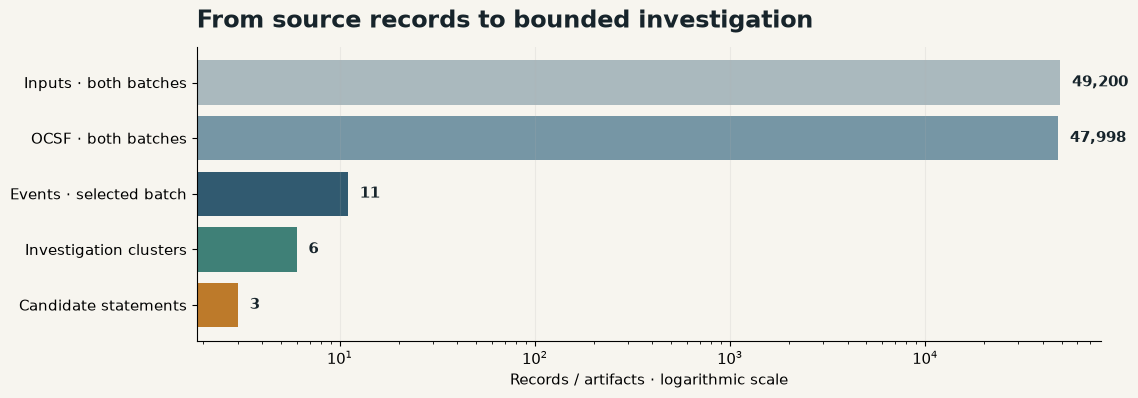

[{'cluster_id': 'leaver-access:P0001:support', 'records': 3},
 {'cluster_id': 'leaver-access:P0002:support', 'records': 4},
 {'cluster_id': 'leaver-access:P0003:support', 'records': 2},
 {'cluster_id': 'leaver-access:P0004:support', 'records': 2},
 {'cluster_id': 'leaver-access:P0005:finance', 'records': 3},
 {'cluster_id': 'leaver-access:P0006:engineering', 'records': 3}]

Model: gpt-4.1-mini-2025-04-14
turn  1 · inspect_pipeline          · pipeline                            · accepted=True
turn  2 · list_evidence_clusters    · pipeline                            · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0001:support         · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0002:support         · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0003:support         · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0004:support         · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0005:finance         · accepted=True
turn  3 · inspect_entity_timeline   · leaver-access:P0006:engineering     · accepted=True
turn  4 · lookup_business_context   · leaver-access:P0001:support         · accepted=True
turn  4 · lookup_business_context   · leaver-access:P0002:support         · accepted=True
turn  4 · lookup_business_context   · leaver-access:P0003:support    

In [6]:
results = []
for batch in (1, 2):
    if LIVE:
        results.append(run(batch))
    else:
        saved = ROOT / f'examples/batch-{batch}.json'
        result = json.loads(saved.read_text(encoding='utf-8'))
        assert result['version'] == VERSION, 'Saved traces are from a different engine revision.'
        assert result['pipeline']['clusters'] == pipelines[batch-1]['clusters'], 'Saved evidence differs from local input. Use live mode for changed inputs.'
        results.append(result)

show_funnel(results[0])
display([{'cluster_id': c['cluster_id'], 'records': len(c['evidence_records'])} for c in results[0]['pipeline']['clusters']])
print('Model:', results[0]['reasoning']['model'])
for event in results[0]['reasoning']['trace']:
    target = event['arguments'].get('cluster_id', 'pipeline')
    print(f"turn {event['turn']:>2} · {event['tool']:<25} · {target:<35} · accepted={event['accepted']}")

## 6 · Review the identified scenarios and their history

The risk statement follows a reviewable structure:

> If a plausible threat event acts through the observed condition, then a potential business consequence may occur, affecting an objective.

The event records support account activity, not the identity of the person operating the account, malicious intent, compromise or loss. A second collection may strengthen, weaken or remove evidence support while the stable scenario ID preserves history.

**Review the model, too:** several saved statements attribute activity to the departed worker when the records only identify the account. Business consequences are broad hypotheses. SEMANTIC-REVIEW.md records these limitations and a more careful editorial formulation; exact model outputs remain visible below.

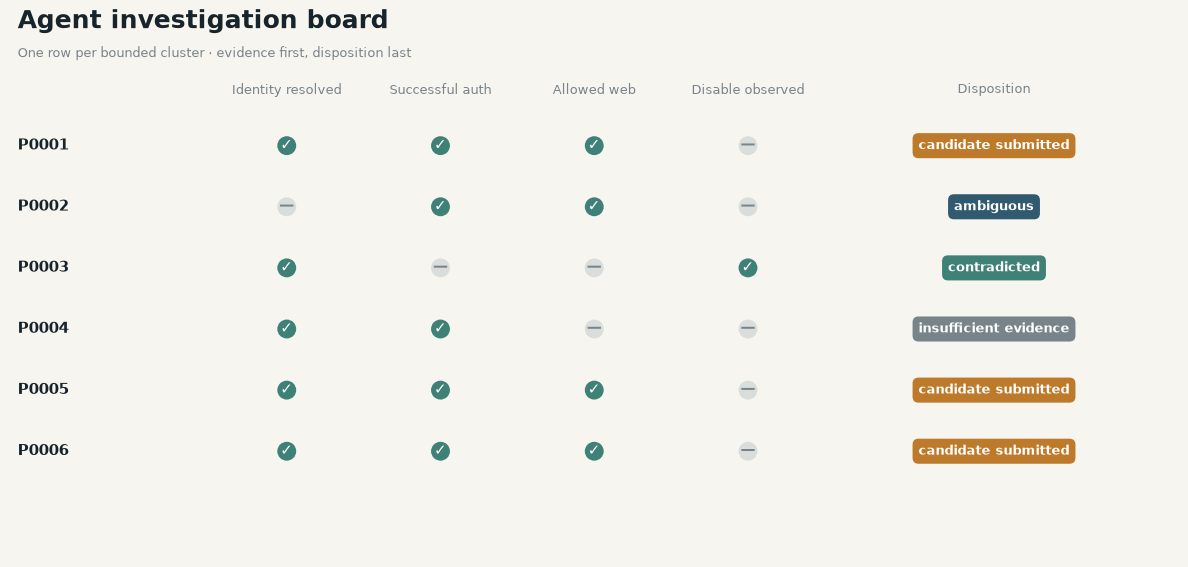

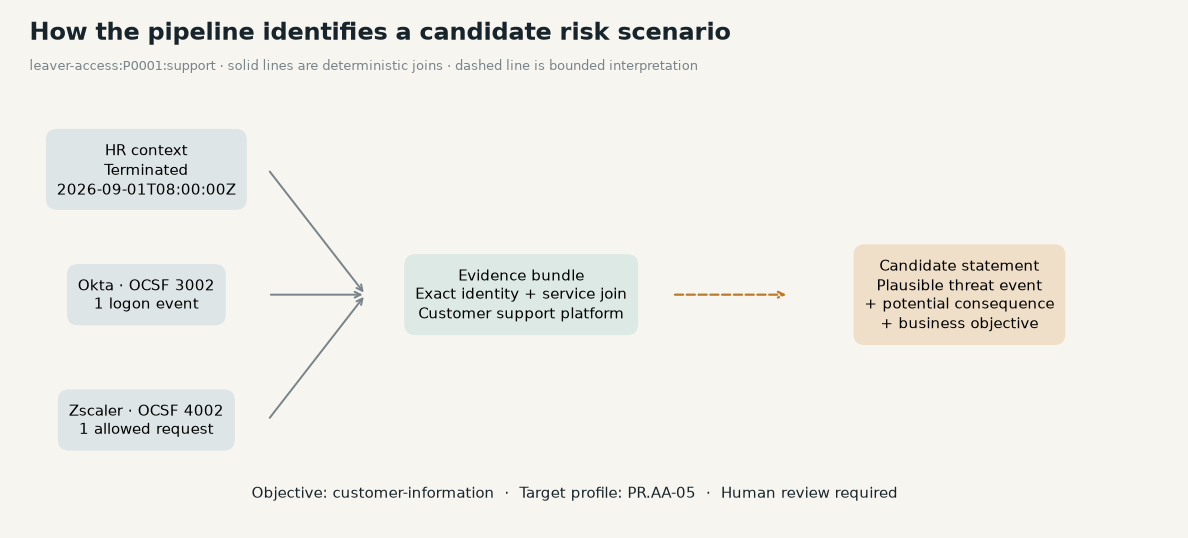

Scenario,Risk statement,Business objective,Evidence,Status
leaver-access:P0001:support,"If terminated user P0001 gains access through successful authentication and allowed web use post-termination, then unauthorized access or data exposure may occur, affecting customer-information confidentiality objectives.",customer-information,"HR-0001, OKTA-P1, ZIA-P1",Candidate
leaver-access:P0005:finance,"If terminated user P0005 gains access through successful authentication and allowed web use post-termination, then unauthorized access or data exposure may occur, affecting financial-reporting objectives.",financial-reporting,"HR-0005, OKTA-P5, ZIA-P5",Candidate
leaver-access:P0006:engineering,"If terminated user P0006 gains access through successful authentication and allowed web use post-termination, then unauthorized access or data exposure may occur, affecting software-delivery objectives.",software-delivery,"HR-0006, OKTA-P6, ZIA-P6",Candidate


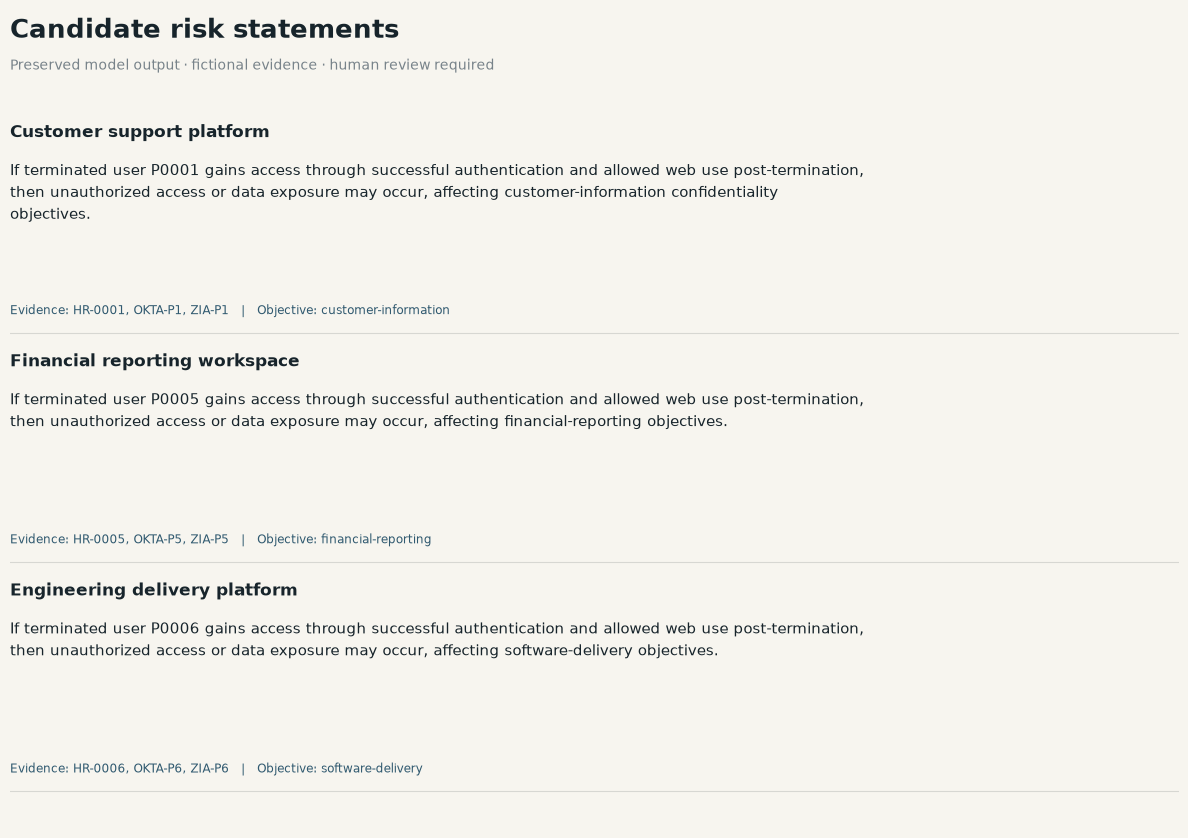

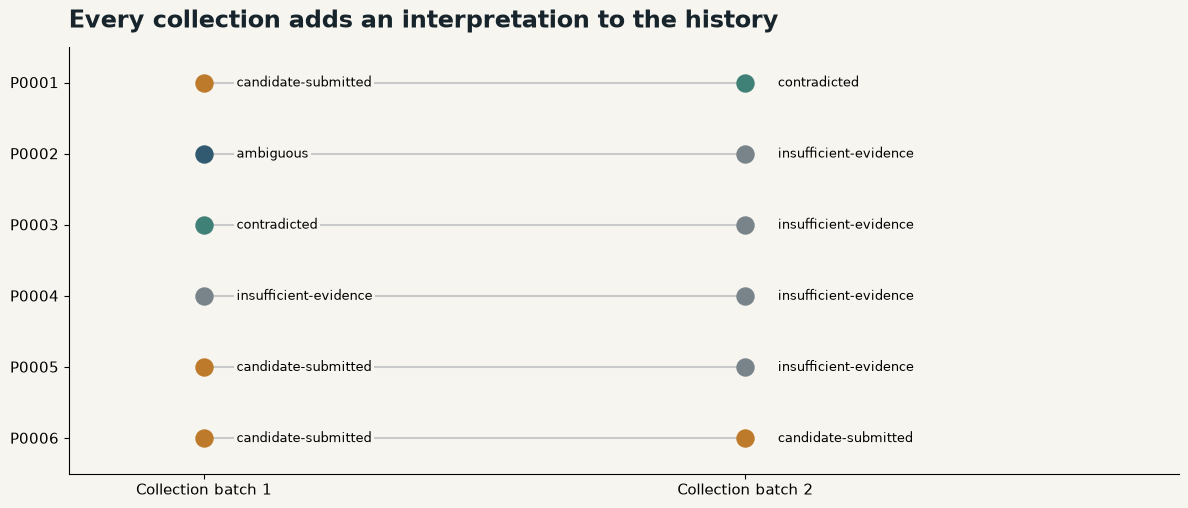

{'batch_1': {'raw_records': 49200,
  'normalized_events': 47998,
  'quarantined': 2,
  'relevant_terminated_user_events': 11,
  'investigation_clusters': 6,
  'supported_evidence_bundles': 3},
 'batch_2': {'raw_records': 49200,
  'normalized_events': 47998,
  'quarantined': 2,
  'relevant_terminated_user_events': 3,
  'investigation_clusters': 6,
  'supported_evidence_bundles': 1}}

In [7]:
show_investigation_board(results[0])
show_evidence(results[0])
show_register(results[0])
show_history(results)

display({'batch_1': results[0]['pipeline']['stage_counts'], 'batch_2': results[1]['pipeline']['stage_counts']})

### Evaluate the workflow, not the prose

The included benchmark contains twelve author-labeled synthetic cases across two collection batches. It tests candidate precision/recall, abstention and contradiction decisions, citation sets, the identification-only boundary, and tool-budget compliance. This is a regression harness—not independent evidence that the approach works on a real enterprise estate.

In [8]:
scorecard = evaluate(results)
display(scorecard)
assert scorecard['passed'], 'Review the failed metric before treating this run as validated.' 

{'benchmark': 'Author-labeled synthetic cases for testing the lab harness; not independent real-world validation.',
 'cases': 12,
 'correct_dispositions': 12,
 'observed_cases_match_benchmark': True,
 'disposition_accuracy': 1.0,
 'candidate_precision': 1.0,
 'candidate_recall': 1.0,
 'unsupported_candidates': 0,
 'citation_sets_valid': True,
 'assessment_language_violations': 0,
 'tool_calls': 47,
 'tool_budget_respected': True,
 'agent_trace_verified': True,
 'baseline_correct_dispositions': 12,
 'model_additional_correct_dispositions': 0,
 'models': ['gpt-4.1-mini-2025-04-14'],
 'interpretation': 'This benchmark tests known-case behavior. It does not establish model superiority or semantic correctness of business consequences.',
 'passed': True}

### Change the input and prove the difference

P0001's second collection contains a disable. Predict what happens if successful authentication and allowed web activity arrive **after** that disable.

The next cell creates an isolated fixture workspace, appends two vendor JSON records, and reruns ingestion, normalization and the reference method. The content hash must change and the same scenario must return to candidate support. This exercise is deterministic and makes no model call. Open exercise.py to change the two timestamps and test the opposite ordering.

In [9]:
from exercise import run_exercise
exercise_result = run_exercise()
display(exercise_result)
assert exercise_result['before'] == 'contradicted'
assert exercise_result['after'] == 'candidate-submitted' 

{'mode': 'local deterministic exercise; no LLM call',
 'scenario_id': 'leaver-access:P0001:support',
 'before': 'contradicted',
 'after': 'candidate-submitted',
 'new_evidence_ids': ['EXERCISE-AUTH-P1', 'EXERCISE-WEB-P1'],
 'before_ingestion_id': 'd65020b6c5439dd9',
 'after_ingestion_id': '80a7ebb87068a224',
 'after_evidence': [{'evidence_id': 'HR-0001',
   'source': 'hr',
   'observed_fact': 'P0001 has employment_status=terminated at 2026-09-01T08:00:00Z; HR expects identity_uid=00u0001.'},
  {'evidence_id': 'OKTA-P1-DISABLE',
   'source': 'Okta',
   'ocsf_class': 'Account Change',
   'observed_fact': 'Okta recorded Disable for user0001@corp.example.test at 1788267660000 with status_id=1. Observed identity_uid=00u0001.'},
  {'evidence_id': 'EXERCISE-AUTH-P1',
   'source': 'Okta',
   'ocsf_class': 'Authentication',
   'observed_fact': 'Okta recorded Logon for user0001@corp.example.test to support at 1788268500000 with status_id=1. Observed identity_uid=00u0001.'},
  {'evidence_id': 'EX

### Inspect the risk-identification contracts

OCSF describes events. Our experimental `RiskEvidenceBundle` links those events to scope, derived conditions, business context, and limitations before the LLM sees them. `CandidateRiskScenario` validates the resulting hypothesis, citations, assumptions, and review status.

These are versioned lab contracts, not an industry standard. HR is optional in the contract; the current offboarding adapter needs HR to establish termination. The current rule selects this scenario family before model reasoning.

In [10]:
from contracts import evidence_bundle, validate_contract
bundle = evidence_bundle(pipelines[0]['clusters'][0])
display(bundle)
scenario = results[0]['reasoning']['candidates'][0]['risk_scenario']
validate_contract('CandidateRiskScenario', scenario)
display(scenario)

{'schema_version': '1.0.0',
 'bundle_id': 'leaver-access:P0001:support',
 'collection_batch': 1,
 'scope': {'identity_ids': ['00u0001'],
  'service_ids': ['support'],
  'start_ms': 1788264720000,
  'end_ms': 1788264840000},
 'evidence': [{'evidence_id': 'HR-0001',
   'source': 'hr',
   'observed_fact': 'P0001 has employment_status=terminated at 2026-09-01T08:00:00Z; HR expects identity_uid=00u0001.'},
  {'evidence_id': 'OKTA-P1',
   'source': 'Okta',
   'ocsf_class': 'Authentication',
   'observed_fact': 'Okta recorded Logon for user0001@corp.example.test to support at 1788264720000 with status_id=1. Observed identity_uid=00u0001.'},
  {'evidence_id': 'ZIA-P1',
   'source': 'Zscaler',
   'ocsf_class': 'HTTP Activity',
   'observed_fact': 'Zscaler recorded Get by user0001@corp.example.test to support.apps.example.test at 1788264840000 with source_action=allowed.'}],
 'derived_conditions': [],
 'business_context': {'objective_id': 'OBJ-001',
  'objective': 'customer-information',
  'serv

{'schema_version': '1.0.0',
 'scenario_id': 'leaver-access:P0001:support',
 'bundle_id': 'leaver-access:P0001:support',
 'collection_batch': 1,
 'observed_condition': 'Terminated user P0001 with one matching observed identity authenticates successfully and accesses allowed web activity to support service post-termination.',
 'threat_event': 'Unauthorized access after termination through lingering credentials or access tokens.',
 'potential_consequence': 'Potential unauthorized access or data exposure affecting customer support platform confidentiality.',
 'risk_statement': 'If terminated user P0001 gains access through successful authentication and allowed web use post-termination, then unauthorized access or data exposure may occur, affecting customer-information confidentiality objectives.',
 'business_context': {'objective_id': 'OBJ-001',
  'objective': 'customer-information',
  'service': 'Customer support platform',
  'owner': 'Business owner 000',
  'data_classification': 'custom

## What you built

You built the first step of a risk engineering lifecycle: continuous identification from changing system evidence. The separation of responsibilities is deliberate:

1. schemas make records interoperable;
2. deterministic code validates, joins, reduces, and abstains;
3. the LLM expresses a bounded scenario from cited evidence and business context;
4. a human decides whether the candidate is useful enough to enter a governed risk process.

### References

- [OCSF schema](https://github.com/ocsf/ocsf-schema) — vendor-neutral security-event structure.
- [Okta System Log](https://developer.okta.com/docs/reference/system-log-query/) — vendor source shape and polling model.
- [NIST CSF 2.0](https://nvlpubs.nist.gov/nistpubs/CSWP/NIST.CSWP.29.pdf) — target-profile outcome context.
- [NIST SP 800-30 Rev. 1](https://nvlpubs.nist.gov/nistpubs/legacy/sp/nistspecialpublication800-30r1.pdf) — threat-event and predisposing-condition concepts; this lab is not a full assessment.

**Cleanup:** stop Jupyter, or run `docker compose down`. Add `-v` only if you intentionally want to delete generated data and history. Never place an API key in this notebook or repository.